# MOwNiT 

## Laboratorium 4

### Interpolacja

Przed uruchomieniem trzeba zainstalować pakiet:

```julia
Pkg.add("Interpolations")
```

In [1]:
using Pkg
Pkg.add("Interpolations")
Pkg.add("Polynomials")
Pkg.add("Measures")

   Resolving package versions...
     Project No packages added to or removed from `~/.julia/environments/v1.12/Project.toml`
    Manifest No packages added to or removed from `~/.julia/environments/v1.12/Manifest.toml`
   Resolving package versions...
     Project No packages added to or removed from `~/.julia/environments/v1.12/Project.toml`
    Manifest No packages added to or removed from `~/.julia/environments/v1.12/Manifest.toml`
   Resolving package versions...
     Project No packages added to or removed from `~/.julia/environments/v1.12/Project.toml`
    Manifest No packages added to or removed from `~/.julia/environments/v1.12/Manifest.toml`


In [2]:
using Plots

In [3]:
# wylosowanie węzłów interpolacji
xs =  1:1:10
ys = [rand() for x in xs]

10-element Vector{Float64}:
 0.6105760063476621
 0.2770214198260931
 0.7195166548246279
 0.00138608832132614
 0.6807090454052593
 0.9518134792266709
 0.33259781712319525
 0.7588132497911924
 0.8882846772876645
 0.8148508451363866

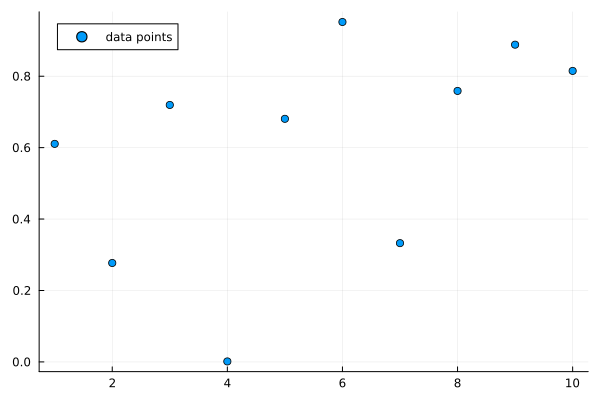

In [4]:
scatter(xs,ys, label="data points")

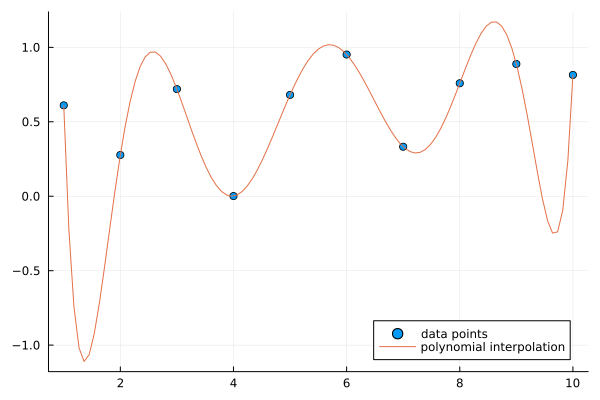

In [5]:
# interpolacja wielomianowa w pakiecie Polynomials
# https://juliamath.github.io/Polynomials.jl/stable/
#import Pkg; Pkg.add("Polynomials")
using Polynomials
f=fit(xs, ys)
plot!(f,  extrema(xs)..., label="polynomial interpolation")

In [6]:
# gęste punkty do rysowania wykresów funkcji interpolujacych
xsf=1:0.01:10

1.0:0.01:10.0

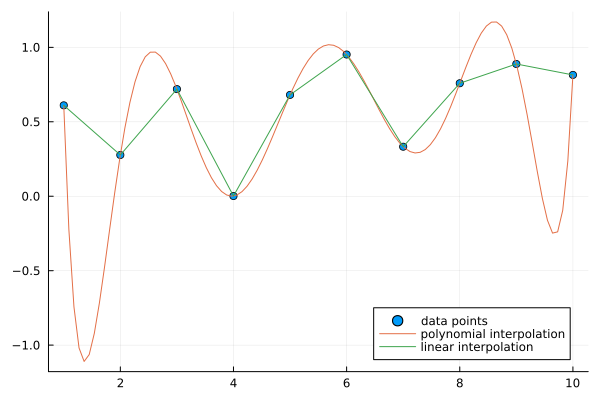

In [7]:
#  interpolacja liniowa z pakietu Interpolations - przykład
using Interpolations
interp_linear = LinearInterpolation(xs, ys)
ysf=[interp_linear(x) for x in xsf]
plot!(xsf,ysf, label="linear interpolation")

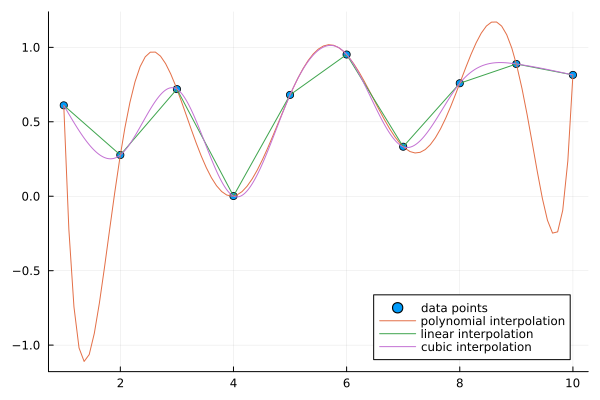

In [8]:
#  interpolacja szescienna 
interp_cubic = CubicSplineInterpolation(xs, ys)
ysf2=[interp_cubic(x) for x in xsf]
plot!(xsf,ysf2, label="cubic interpolation")

In [9]:
#Interpolacja szescienna to BSpline z warunkami brzegowymi Line i OnGrid. 
#Więcej o konfiguracji warunkow brzegowych w
# dokumentacji https://github.com/JuliaMath/Interpolations.jl/blob/master/doc/Interpolations_algebra.pdf
interp_cubic

10-element extrapolate(scale(interpolate(OffsetArray(::Vector{Float64}, 0:11), BSpline(Cubic(Line(OnGrid())))), (1:1:10,)), Throw()) with element type Float64:
 0.6105760063476621
 0.2770214198260931
 0.7195166548246279
 0.0013860883213261954
 0.6807090454052594
 0.951813479226671
 0.33259781712319525
 0.7588132497911922
 0.8882846772876645
 0.8148508451363867

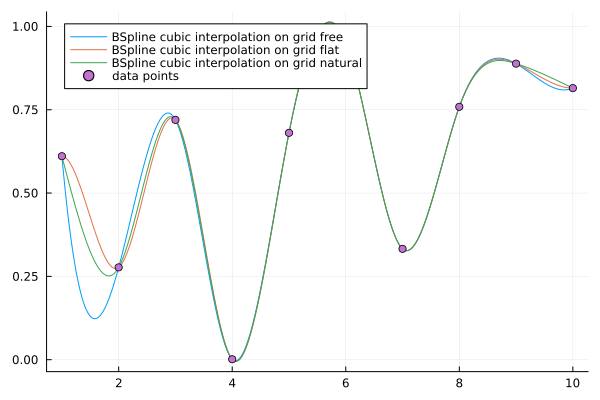

In [10]:
# Przyklad konfiguracji  BSpline-ów
itp = interpolate(ys, BSpline(Cubic(Free(OnGrid()))))
ysf3=[itp(x) for x in xsf]
plot(xsf,ysf3, label="BSpline cubic interpolation on grid free")
itp = interpolate(ys, BSpline(Cubic(Flat(OnGrid()))))
ysf3=[itp(x) for x in xsf]
plot!(xsf,ysf3, label="BSpline cubic interpolation on grid flat")
itp = interpolate(ys, BSpline(Cubic(Natural(OnGrid()))))
ysf3=[itp(x) for x in xsf]
plot!(xsf,ysf3, label="BSpline cubic interpolation on grid natural")

scatter!(xs,ys, label="data points")


### 1. Napisać własną implementację interpolacji wielomianowej stosując wprost wzór na wielomian interpolacyjny  Lagrange'a .  Przetestować swoją implementację na wylosowanych węzłach interpolacji w wybranym przedziale. Narysować wykres wielomianu interpolacyjnego w tym przedziale wraz z wezlami interpolacji. <b>(1 pkt)</b>

In [11]:
# Lagrange Interpolation

function lagrange_factor(xs::AbstractVector, n::Int, k::Int, x::Number)::Float64
    d = m = 1
    x_k = xs[k]
    
    for i in 1:n
        if i != k
            x_i = xs[i]
            d *= (x - x_i)
            m *= (x_k - x_i)
        end
    end
    
    return d / m
end

function lagrange_interpolation(xs::AbstractVector, ys::AbstractVector, x::Number)::Float64
    n = length(xs)
    polynomial_val = 0 
    
    for i in 1:n
        y_i = ys[i] 
        polynomial_val += y_i * lagrange_factor(xs, n, i, x)
    end

    return polynomial_val
end


lagrange_interpolation (generic function with 1 method)

In [12]:
# data
xs =  1:1:10
ys = [rand() for x in xs]
xsf=1:0.01:10


1.0:0.01:10.0

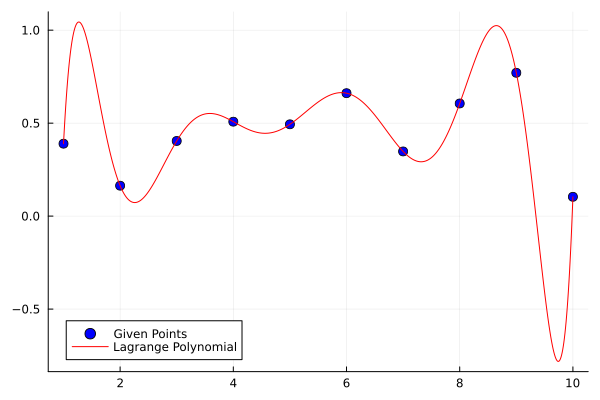

In [13]:
# Plotting
using Plots

y_lagrange = [lagrange_interpolation(xs, ys, x) for x in xsf]

p = scatter(xs, ys, 
    label="Given Points", 
    color=:blue, 
    markersize=5)

plot!(p, xsf, y_lagrange, 
    label="Lagrange Polynomial", 
    color=:red, 
    lw=1)

display(p)

<br>
<br>


### 2. Zrobic to samo dla metody  Newtona (metoda ilorazów róznicowych).Narysować wykres wielomianu interpolacyjnego otrzymanego metodą Newtona dla tych samych danych, co w poprzednim punkcie. Zadbać o to, żeby ilorazy wyliczać tylko raz dla danego zbioru wezłow interpolacji, według schematu z pakietu Interpolations http://juliamath.github.io/Interpolations.jl/stable/interpolations/ : 
   ### - napisać funkcję `NewtonInterpolation`, która wylicza ilorazy różnicowe i zwraca "obiekt interpolacyjny" `newt`
   ### - napisać funkcję która wylicza wartość wielomianu dla obiektu `newt` w punkcie x za pomocą  <b>schematu Hornera dla postaci Newtona </b> <b>(2 pkt)</b>

In [14]:
# Newton Interpolation

struct NewtonPoly
    xs::AbstractVector
    diff_qts::AbstractVector
end

# Create object contains xs: Array with diff_qts: differential quotients Array 
function newton_interpolation(xs::AbstractVector, ys::AbstractVector)::NewtonPoly
    n = length(xs)
    diff_qts = copy(ys)
    
    for j in 2:n
        for i in n:-1:j
            # 
            diff_qts[i] = (diff_qts[i] - diff_qts[i-1]) / (xs[i] - xs[i-j+1])
        end
    end
    
    return NewtonPoly(xs, diff_qts)
end

# Horner
function evaluate_newton(newt::NewtonPoly, x::Number)::Float64
    n = length(newt.diff_qts)
    result = newt.diff_qts[n]
    #Pn(x)=f[x1]+(x−x1)*(f[x1,x2]+(x−x2)*(f[x1,x2,x3]+⋯+(x−xn−1)f[x1...xn])
    for i in (n-1):-1:1
        result = newt.diff_qts[i] + (x - newt.xs[i]) * result
    end
    
    return result
end



evaluate_newton (generic function with 1 method)

<br>
<br>

### 3. Zastosować interpolację wielomianową z pakietu Polynomials do tych samych danych, co w poprzednich punktach. Porównać wszystkie 3 wyniki interpolacji wielomianowej na jednym wykresie. Co zauważamy? Dlaczego? <b>(1 pkt)</b>

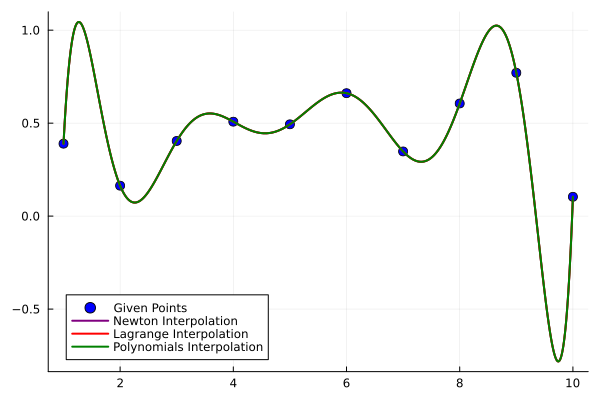

In [15]:
# compare all 3 on plot

using Polynomials
using Plots

# Create newton struct
newton_struct = newton_interpolation(xs, ys)

y_poly = fit(xs, ys).(xsf) # <- Polynomials Interpolation
y_newton = [evaluate_newton(newton_struct, x) for x in xsf] # <- Newton Interpolation
y_lagrange = [lagrange_interpolation(xs, ys, x) for x in xsf] # <- Lagrange Interpolation

# Plotting
p = scatter(xs, ys, 
    label="Given Points", 
    color=:blue, 
    markersize=5)

plot!(p, xsf, y_newton, 
    label="Newton Interpolation", 
    linewidth=2,           
    color=:purple)

plot!(p, xsf, y_lagrange, 
    label="Lagrange Interpolation", 
    linewidth=2,     
    color=:red)

plot!(p, xsf, y_poly, 
    label="Polynomials Interpolation", 
    linewidth=2,      
    color=:green)

display(p)


<br>
<br>

### 4. Porównać metody poprzez pomiar czasu wykonania dla zmiennej ilości węzłow interpolacji. Uwaga: dodatkowo, dla metody Newtona i pakietu Polynomials należy osobno zmierzyć czas wyliczania wielomianu i osobno czas wyliczania wartości w punkcie. Dokonać pomiaru 10 razy i policzyć wartość średnią oraz oszacować błąd pomiaru za pomocą odchylenia standardowego; wyniki przedstawić na wykresach. <b>(2 pkt)</b>

In [16]:
# Benchmarks

using Statistics
using DataFrames
using Polynomials

function generate_data(cnt)
    xs = 1:1:cnt
    ys = [rand() for x in xs]
    return xs, ys
end
    
function run_benchmarks()
    points_cnt = [10, 20, 50, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]
    df = DataFrame(n = Int[], algorithm = String[], stage = String[], time = Float64[])
    
    for cnt in points_cnt
        for i in 1:10
            xs, ys, = generate_data(cnt)
            
            # Newton Interpolation
            # build struct time
            t_newt_build = @elapsed newt_struct = newton_interpolation(xs, ys)
            push!(df, (cnt, "Newton", "Build", t_newt_build))
            # eval time
            t_newt_eval = @elapsed [evaluate_newton(newt_struct, x) for x in xs]
            push!(df, (cnt, "Newton", "Eval", t_newt_eval))

            # Polynomials Interpolation
            # build struct time
            t_poly_build = @elapsed poly_struct = fit(xs, ys)
            push!(df, (cnt, "Polynomials", "Build", t_poly_build))
            # eval time
            t_poly_eval = @elapsed [poly_struct(x) for x in xs]
            push!(df, (cnt, "Polynomials", "Eval", t_poly_eval))
                
            # Lagrange Interpolation
            t_lagrange = @elapsed [lagrange_interpolation(xs ,ys, x) for x in xs]
            push!(df, (cnt, "Lagrange", "Total", t_lagrange))
            
        end
    end
    
    final_df = combine(groupby(df, [:n, :algorithm, :stage]), 
        :time => mean => :mean_time, 
        :time => std => :std_dev
    )
    return final_df
end

run_benchmarks (generic function with 1 method)

In [17]:
df = run_benchmarks()

Row,n,algorithm,stage,mean_time,std_dev
,Int64,String,String,Float64,Float64
1,10,Newton,Build,9.253e-7,2.2119e-6
2,10,Newton,Eval,1.79665e-5,2.40771e-5
3,10,Polynomials,Build,2.3959e-6,4.94795e-6
4,10,Polynomials,Eval,0.00154535,0.00488478
5,10,Lagrange,Total,2.6458e-6,3.42452e-6
6,20,Newton,Build,6.332e-7,1.32961e-7
7,20,Newton,Eval,4.05625e-5,2.03064e-6
8,20,Polynomials,Build,7.917e-7,1.72285e-7
9,20,Polynomials,Eval,5.082e-7,5.49925e-8


In [18]:
using Plots

# parsing
df_nb = df[(df.algorithm .== "Newton") .& (df.stage .== "Build"), :]
df_ne = df[(df.algorithm .== "Newton") .& (df.stage .== "Eval"), :]
df_pb = df[(df.algorithm .== "Polynomials") .& (df.stage .== "Build"), :]
df_pe = df[(df.algorithm .== "Polynomials") .& (df.stage .== "Eval"), :]
df_lag = df[df.algorithm .== "Lagrange", :]

# Newton Build
p_build_newton = plot(df_nb.n, df_nb.mean_time, yerror=df_nb.std_dev, title="Newton Build Time", xlabel="Node count", ylabel="time [s]", label="Newton Build", color=:blue, marker=:circle, size=(800, 500))

# Poly Build
p_build_poly = plot(df_pb.n, df_pb.mean_time, yerror=df_pb.std_dev, title="Poly Build Time", xlabel="Node count", ylabel="time [s]", label="Poly Build", color=:green, marker=:circle, size=(800, 500))

# Newton Eval
p_eval_newton = plot(df_ne.n, df_ne.mean_time, yerror=df_ne.std_dev, title="Newton Evaluation Time", xlabel="Node count", ylabel="time [s]", label="Newton Eval", color=:cyan, marker=:circle, size=(800, 500))

# Poly Eval
p_eval_poly = plot(df_pe.n, df_pe.mean_time, yerror=df_pe.std_dev, title="Poly Evaluation Time", xlabel="Node count", ylabel="time [s]", label="Poly Eval", color=:purple, marker=:circle, size=(800, 500))

# Lagrange
p_lag = plot(df_lag.n, df_lag.mean_time, yerror=df_lag.std_dev, title="Lagrange Time", xlabel="Node count", ylabel="time [s]", label="Lagrange", color=:red, marker=:circle, size=(800, 500));

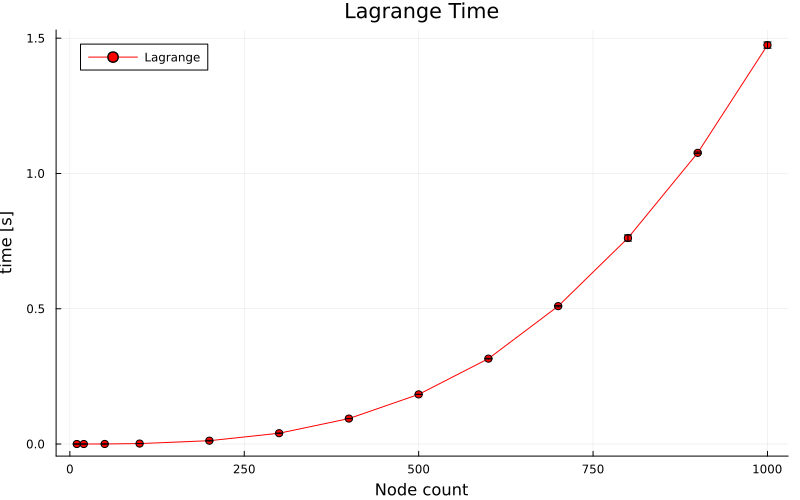

In [19]:
display(p_lag)

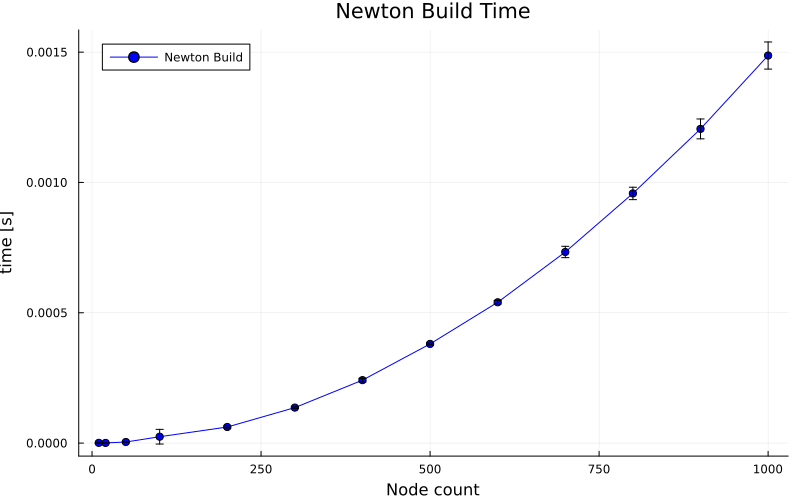

In [20]:
display(p_build_newton)

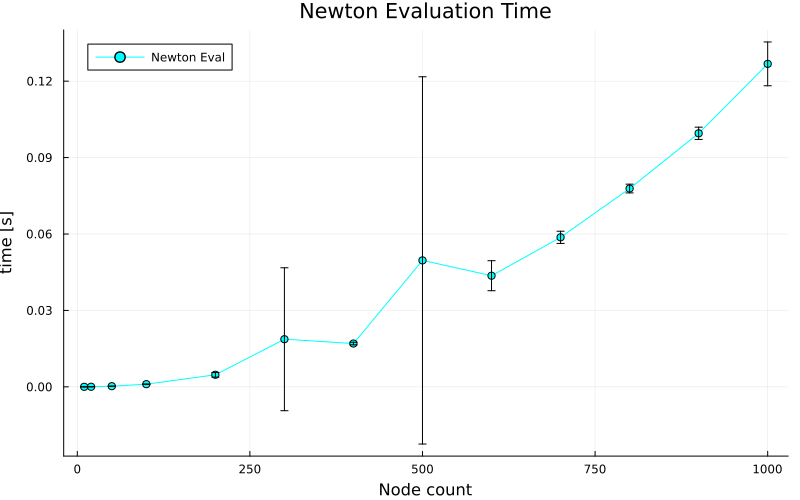

In [21]:
display(p_eval_newton)

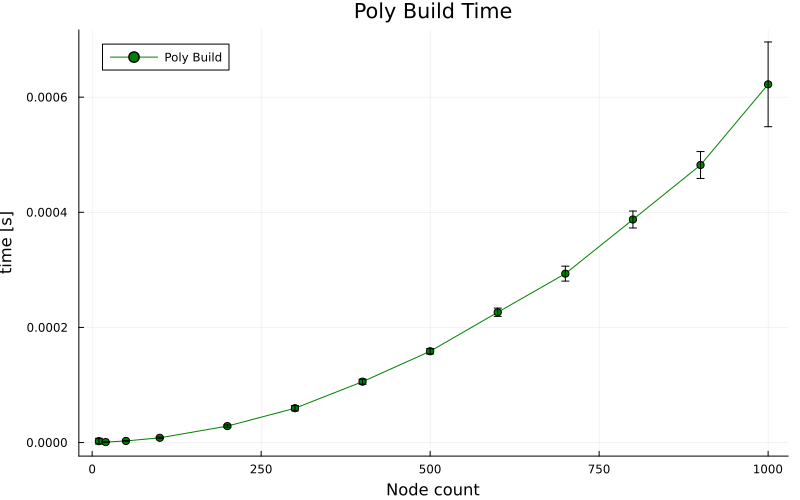

In [22]:
display(p_build_poly)

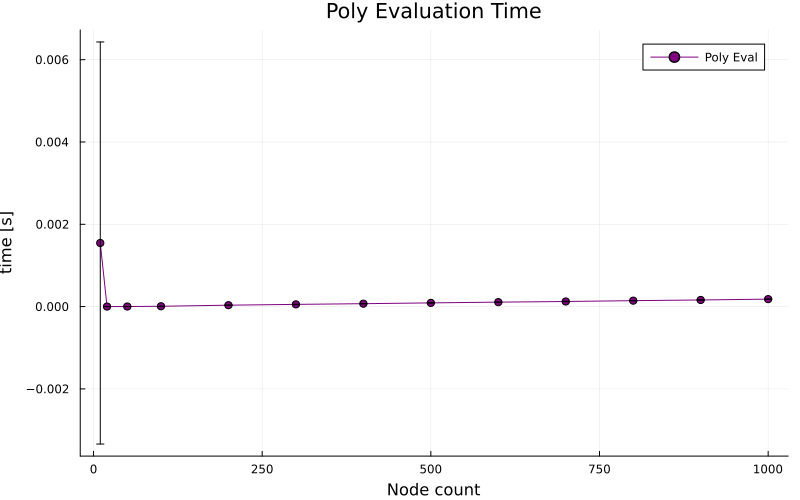

In [23]:
display(p_eval_poly)

<br>
<br>


### 5. Zaimplementować algorytm Neville’a i sprawdzić (dla kilku wybranych punktów), czy daje te same wartości wielomianu co wybrana interpolacja wielomianowa.<b>(1 pkt)</b>

In [24]:
# Neville 
function neville(xs::AbstractVector, ys::AbstractVector, x::Number)::Float64
    n = length(xs)
    dp = fill(NaN, n, n)
    
    function rec(i, j)
        if !isnan(dp[i, j])
            return dp[i, j]
        end
        
        if i == j
            dp[i, j] = ys[i]
            return dp[i, j]
        end
        
        p1 = rec(i, j-1)
        p2 = rec(i+1, j)
        
        result = ((x - xs[j]) * p1 + (xs[i] - x) * p2) / (xs[i] - xs[j])
        dp[i, j] = result
        return result
        
    end
    
    return rec(1, n)
end


neville (generic function with 1 method)

In [25]:
# Nevile & Newton comparsion
using Printf
xs = 1:1:5
ys = [rand() for x in xs]
x_tests = [0.99, 1.23, 2.2, 3.5, 4.3]

newt_struct = newton_interpolation(xs, ys)

@printf("%-10s | %-15s | %-15s | %-10s\n", "X", "Neville", "Newton", "Difference")

for xt in x_tests
    nev_res = neville(xs, ys, xt) 
    newt_res = evaluate_newton(newt_struct, xt)
    diff = abs(nev_res - newt_res)
    
    @printf("%-10.2f | %-15.8f | %-15.8f | %-10.2e\n", xt, nev_res, newt_res, diff)
end

X          | Neville         | Newton          | Difference
0.99       | 0.22195304      | 0.22195304      | 2.78e-17  
1.23       | 0.29390632      | 0.29390632      | 0.00e+00  
2.20       | 0.09789716      | 0.09789716      | 0.00e+00  
3.50       | 0.11177755      | 0.11177755      | 0.00e+00  
4.30       | 0.40340238      | 0.40340238      | 1.11e-16  


<br>
<br>

### 6. Poeksperymentować z  interpolacją funkcjami sklejanymi (minimum dwie różne funkcje sklejane),  narysować wykresy i porównać z wykresami interpolacji wielomianowej. <b>Zademonstrować  efekt Rungego</b> <b>(1 pkt)</b>. 

In [32]:
# data
using Interpolations
using Plots

# runge func
f_runge(x) = 1 / (1 + 25x^2)
n = 11
xs = range(-1, 1, length=n)
ys = f_runge.(xs)

xsf = -1:0.005:1
ysf = f_runge.(xsf);

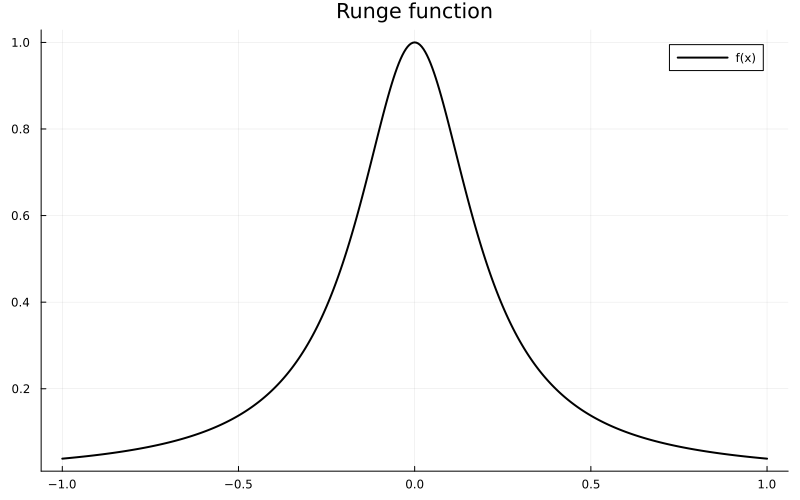

In [33]:
# Runge function plot
p_runge = plot(xsf, ysf, title="Runge function", label="f(x)", lw=2, color=:black, size=(800, 500))
display(p_runge)

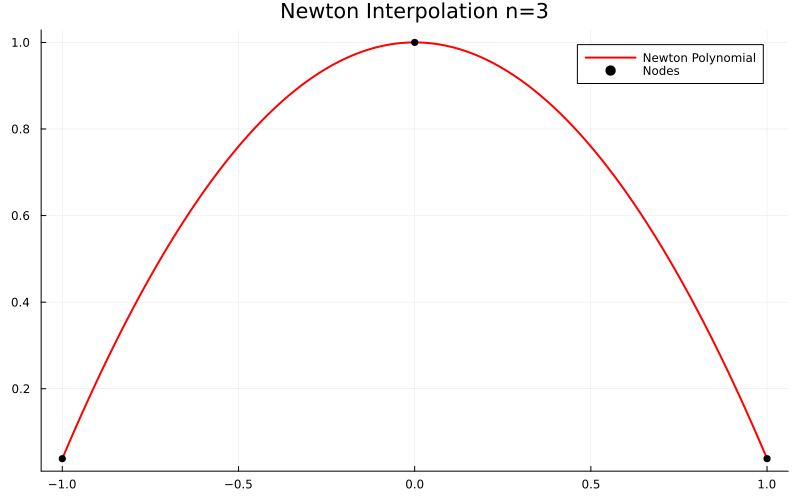

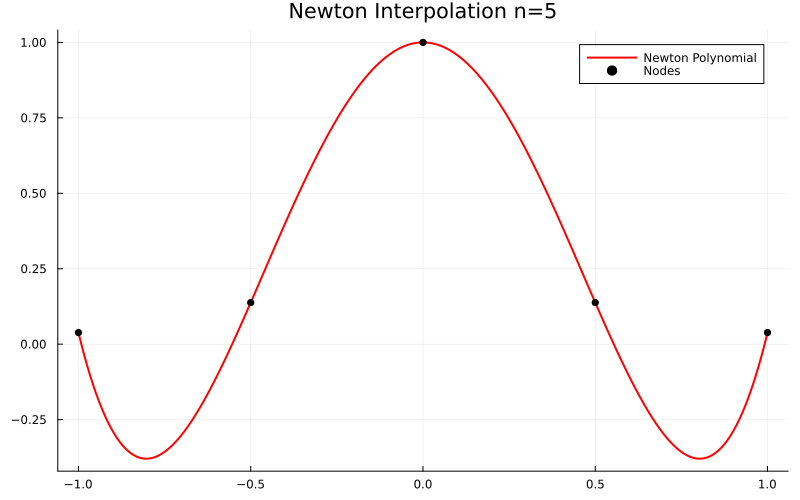

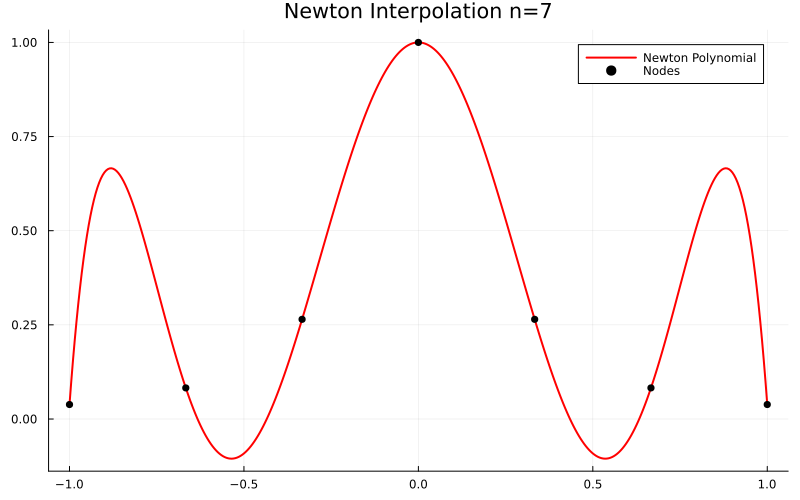

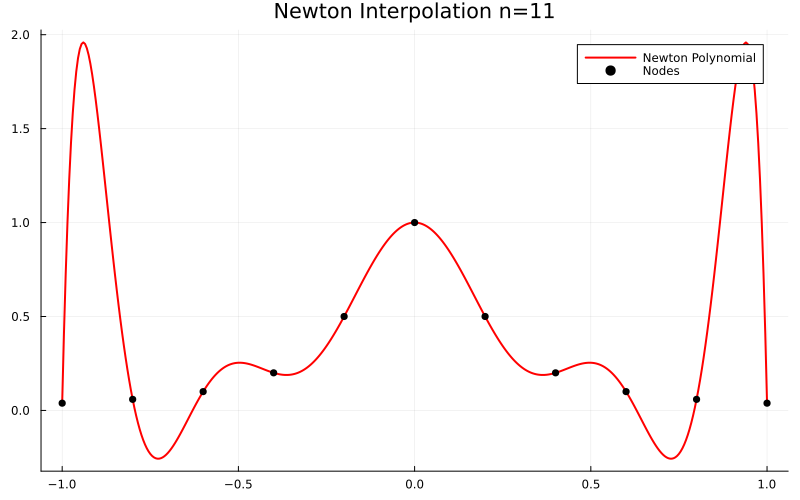

In [34]:
# Runge effect
for n in [3, 5, 7, 11]
    xs = range(-1, 1, length=n)
    ys = f_runge.(xs)
    
    newt_struct = newton_interpolation(xs, ys)
    y_newton = [evaluate_newton(newt_struct, x) for x in xsf]
    
    p_newt = plot(xsf, y_newton, title="Newton Interpolation n=$n", label="Newton Polynomial", color=:red, lw=2, size=(800, 500))
    scatter!(p_newt, xs, ys, label="Nodes", color=:black)
    
    plot!(p_newt)
    display(p_newt)
end
# 0.726 < |x| < 1

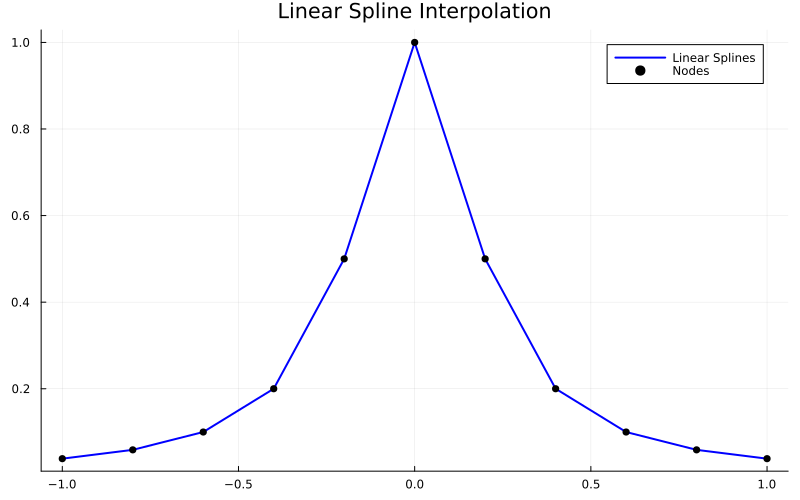

In [35]:
# Linear spline
linear_spline_interpolation = LinearInterpolation(xs, ys)
y_linear_spline = [linear_spline_interpolation(x) for x in xsf]
p_linear = plot(xsf, y_linear_spline, title = "Linear Spline Interpolation", label="Linear Splines", color=:blue, lw=2, size=(800, 500))
scatter!(p_linear, xs, ys, label="Nodes", color=:black)
display(p_linear)

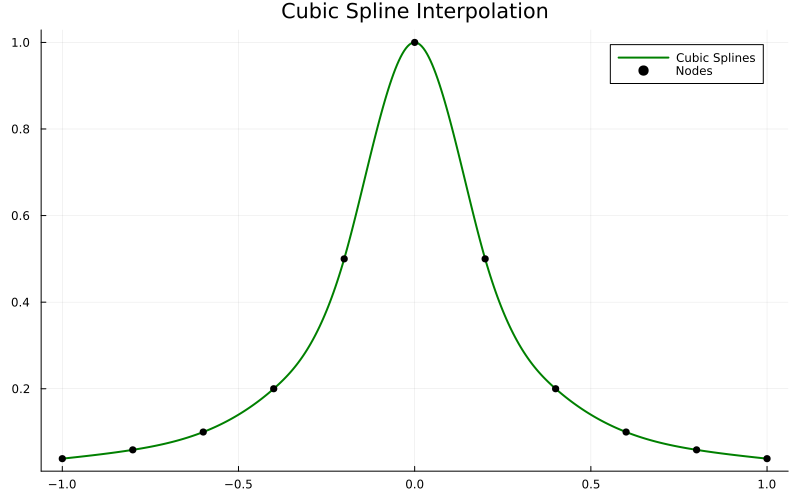

In [36]:
# Cubic spline
cubic_spline_interpolation = Interpolations.cubic_spline_interpolation(xs, ys)
y_cubic_spline = [cubic_spline_interpolation(x) for x in xsf]
p_cubic = plot(xsf, y_cubic_spline, title = "Cubic Spline Interpolation", label="Cubic Splines", color=:green, lw=2, size=(800, 500))
scatter!(p_cubic, xs, ys, label="Nodes", color=:black)
display(p_cubic)

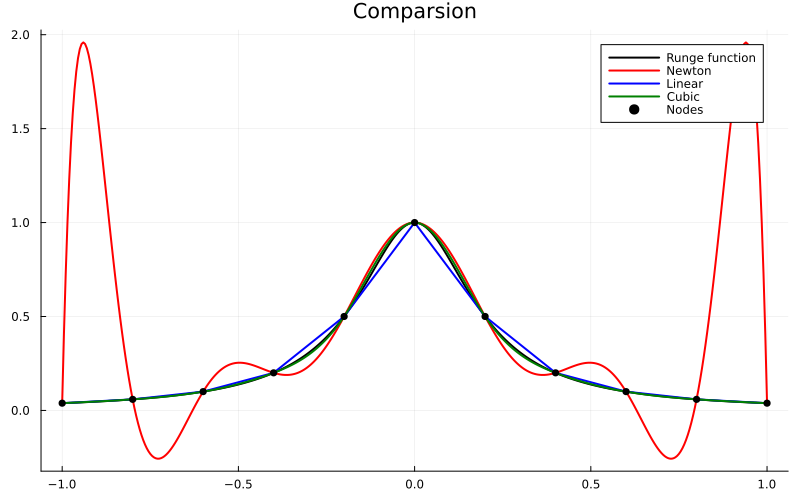

In [37]:
# Comparsion
p_all = plot(xsf, ysf, label="Runge function", lw=2, color=:black)

plot!(p_all, xsf, y_newton, label="Newton", color=:red, lw=2)
plot!(p_all, xsf, y_linear_spline, label="Linear", color=:blue, lw=2)
plot!(p_all, xsf, y_cubic_spline, label="Cubic", color=:green, lw=2)

scatter!(p_all, xs, ys, label="Nodes", color=:black)
plot!(p_all, title="Comparsion", size=(800, 500))
display(p_all)